# Configurações Gerais

In [1]:
#Preparação do sistema para correr o programa
import os
gpu_num = 0 # Use "" to use the CPU or 0 to use GPU
os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


try: # Detetar se é possivel previsualizar 
    import google.colab
    colab_compat = True # Desativar preview
except:
    colab_compat = False
resolution = [480,320] # Maior qualidade de rederização

# Permitir saida das celulas no Jupiter
class ExitCell(Exception):
    def _render_traceback_(self):
        pass


try: 
    import sionna
except ImportError as e: #Instalará do Sionna caso este não esteja instalado
    
    import os
    os.system("pip install sionna")
    import sionna

# Configura para usar apenas uma única GPU(Processadore alocar a memória necessária que precisas
# Mais informações: https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

tf.random.set_seed(1) # Set global random seed for reproducibility


# Importação das funções para o programa funcionar

In [2]:
#Importa as funções necessárias para o programa

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time

# Import Sionna RT components
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, Camera

# For link-level simulations
from sionna.channel import cir_to_ofdm_channel, subcarrier_frequencies, OFDMChannel, ApplyOFDMChannel, CIRDataset
from sionna.nr import PUSCHConfig, PUSCHTransmitter, PUSCHReceiver
from sionna.utils import compute_ber, ebnodb2no, PlotBER
from sionna.ofdm import KBestDetector, LinearDetector
from sionna.mimo import StreamManagement


# Importação da cena para usar ao longo do programa

Conceitos

Usar .. para retornar uma pasta atrás
Sempre que indicar uma pasta seguinte deve usar "/"(Usar esta barra e não a barra "\")

Ao indicar o localização do ficheiro a carregar devemos sempre ter em conta a pasta onde nos encontramos e a partir daí usar 

/pasta_seguinte ou ../pasta_anterior

Supondo o nosso ficheiro se encontra numa pasta chamada Sionna(e esta pasta está no ambiente de trabalho) e que o ficheiro(Projeto) que estamos a usar está na raiz(pasta default do Jupyter)
Devemos usar load_scene("Desktop/Sionna/Nome_atribuido_ao_ficheiro.xml")


In [3]:
scene = load_scene(sionna.rt.scene.etoile) # Carregar a cena escolhida
scene.preview() #Cria uma previsualização do cenário

Renderer(camera=PerspectiveCamera(aspect=1.31, children=(DirectionalLight(intensity=0.25, position=(0.0, 0.0, …

# Criação dos array para transmissão e receção

In [4]:
# Configuração do array da antenas para todos os transmissores
scene.tx_array = PlanarArray(
                          num_rows=8,             #Linhas
                          num_cols=2,             # Colunas
                          vertical_spacing=0.7,   # Espaço Vertical entre antenas
                          horizontal_spacing=0.5, # Espaço Horizontal entre antenas
                          pattern="dipole",      # “iso”, “dipole”, “hw_dipole”, “tr38901”
                          polarization="VH")      # V(Vertical), H(Horinzontal) ou VH(Vertical e Horizontal) 

# Configure antenna array para todos os recetores
scene.rx_array = PlanarArray(num_rows=1,
                          num_cols=1,
                          vertical_spacing=0.5,
                          horizontal_spacing=0.5,
                          pattern="dipole",
                          polarization="cross")



(<Figure size 640x480 with 2 Axes>, <Figure size 640x480 with 1 Axes>)

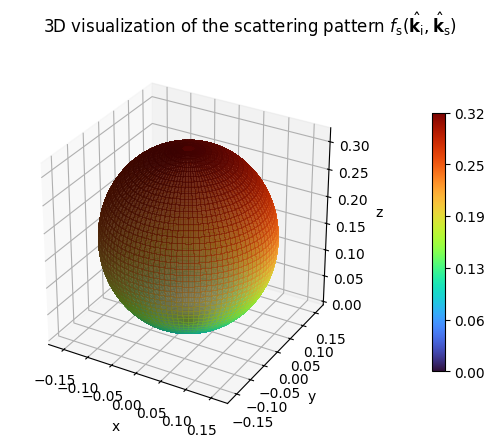

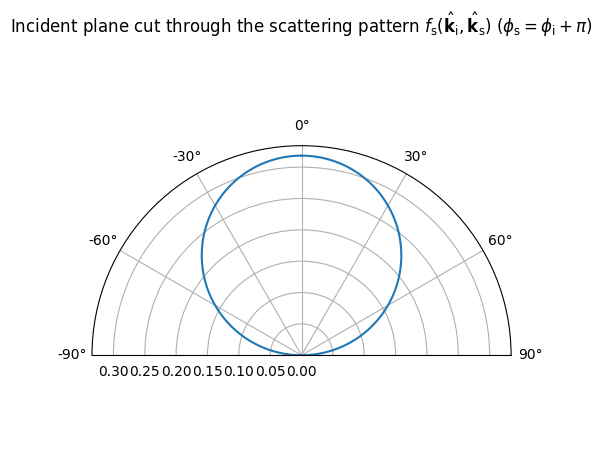

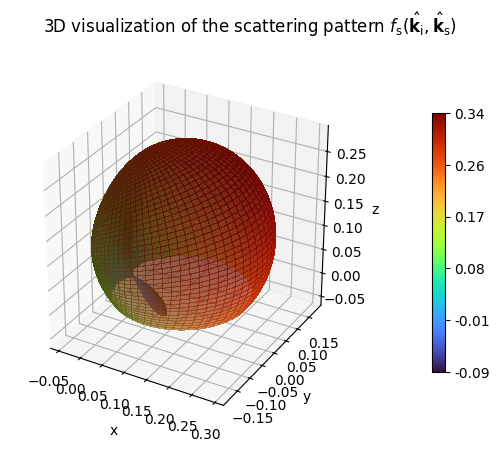

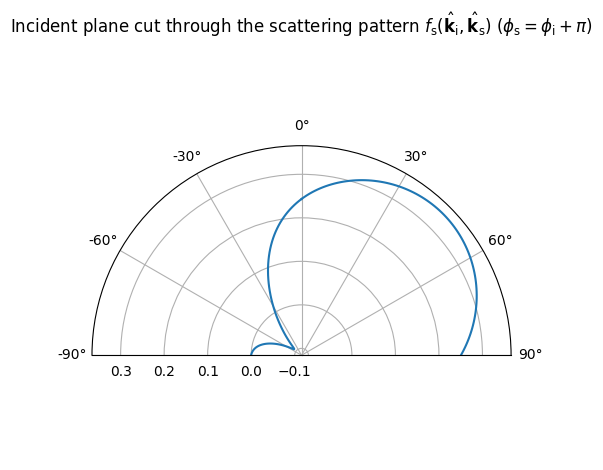

In [5]:
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, RadioMaterial, Camera, LambertianPattern, DirectivePattern, BackscatteringPattern
from random import randint
#k_i = (0.7071, 0., -0.7071) # Incoming directions(x,y,z)
#k_s = (0.80, 0., -0.7071)
#n_hat = 
#alpha_r = 
#alpha_i = 
#angle_lambda = 
#k_i = 1
#k_s = 2
#n_hat = 10
#alpha_r = 0.5
#alpha_i = 3.1416 / 4
#lambda_ = 3
#ScatteringPattern = (alpha_r=2, alpha_i=20, lambda_=2)
LambertianPattern().visualize()
BackscatteringPattern(alpha_r=2, alpha_i=20, lambda_=2).visualize()


# Criação de um transmissor e um recetor

In [6]:
# Cria um transmissor
tx = Transmitter(name="tx",
              position=[8.5,21,27],
              orientation=[0,0,0])
scene.add(tx)

# Cria um recetor
rx = Receiver(name="rx",
           position=[45,90,1.5],
           orientation=[0,0,0])
scene.add(rx)

# TX points towards RX
tx.look_at(rx)

print(f"Posição do transmissor: {tx.position[0]},{tx.position[1]},{tx.position[2]}")
print(f"Posição do recetor: {rx.position[0]},{rx.position[1]},{rx.position[2]}")

Posição do transmissor: 8.5,21.0,27.0
Posição do recetor: 45.0,90.0,1.5


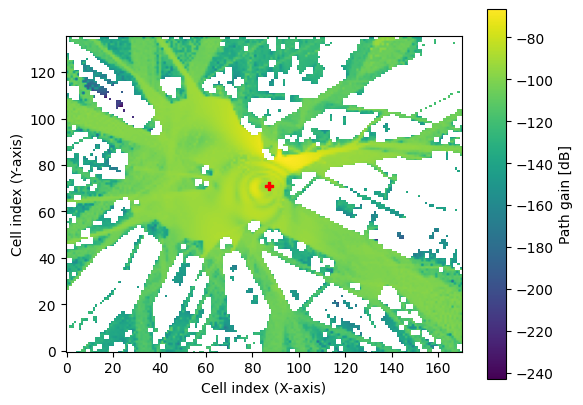

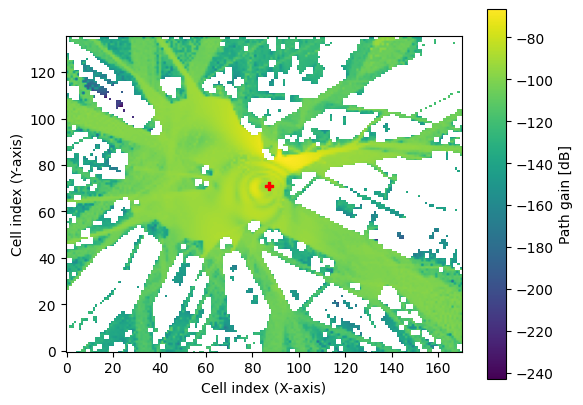

In [7]:
#Criação do coverage map
cm = scene.coverage_map(max_depth=5,
                        diffraction=True, # Disable to see the effects of diffraction
                        cm_cell_size=(5., 5.), # Grid size of coverage map cells in m
                        combining_vec=None,
                        precoding_vec=None,
                        num_samples=int(5e6)) # Reduce if your hardware does not have enough memory
cm.show()


# Calculo da coordenada Z(coverage_map_dB)
Retirar valor da coordenada Z(coverage_map_dB) 

In [20]:
import math

#Calculo do cove
cmx = 50
cmy =  60
#coverage_map_watts = cm[0,cmy,cmx].numpy()

#Calculo de nivel através das coordenadas
if cm[0,cmy,cmx].numpy() != 0:
    coverage_map_watts = cm[0,cmy,cmx].numpy()
    coverage_map_dB = 10 * math.log10(coverage_map_watts)
else:
    coverage_map_dB = 0

print(f"{coverage_map_dB:.3f} dB")  # Likely prints the same value repeatedly




-95.310 dB


# Calculo coordenada Z(coverage_map_dB) para todas as coordenadas 
x[Cell index (X-assis)], y[Cell index (Y-assis)], 
De modo a obter z(coverage_map_dB)

In [9]:
#Definição de niveis máximos das coordenadas x,y do coverage map
cmxmax = 170
cmymax = 135

#Para todos os ponto x,y vai ser calculado o z 
def export(x, y, z):
  with open("variaveis.txt", "a") as arquivo:
    arquivo.write(f"{x};{y};{z}\n")  # Add newline for proper formatting



for x in range(cmxmax):
  for y in range(cmymax):
    z_watts = cm[0, y, x].numpy()  # Access element using correct indexing

    if z_watts:
        z = 10 * math.log10(z_watts)
        print(x, y, z)
        export(x, y, z)
    else:
        z = 0  # Set z to a meaningful value



0 6 -126.24771554286978
0 7 -126.69862862245878
0 8 -127.30178275349726
0 9 -116.55233204490452
0 22 -128.9358948393856
0 25 -120.04193298474347
0 26 -104.69146386484964
0 27 -106.11756739290358
0 28 -119.11307064332986
0 29 -124.17267728018638
0 30 -129.37174996261967
0 31 -126.37193451135363
0 34 -150.5904358770873
0 35 -127.66060399310435
0 36 -130.7024342956436
0 37 -128.0175337074041
0 38 -151.57896610013242
0 39 -117.8423189434089
0 40 -104.68174789478991
0 41 -113.50676831563231
0 42 -109.37888575218707
0 43 -132.74809631102025
0 44 -121.46787406916039
0 45 -113.5331680206647
0 46 -96.1910037677113
0 47 -100.20340289010447
0 48 -110.51011688347556
0 49 -108.10634513102222
0 50 -106.36413537253453
0 51 -107.12209399848658
0 52 -107.03656557657291
0 53 -111.08831145497787
0 55 -131.1147710889931
0 56 -126.97591396565696
0 58 -133.25243021419607
0 59 -137.12449502064987
0 60 -144.09531626849
0 61 -112.49815497059001
0 62 -148.36252652385252
0 63 -121.23368896518875
0 64 -100.448671